In [3]:
from networkx.readwrite import json_graph
import json
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [4]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mikke\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [5]:
with open("rfa_agree_graph_with_communities.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G_agree = json_graph.node_link_graph(data)

In [6]:
print(f"Number of nodes: {G_agree.number_of_nodes()}")
print(f"Number of edges: {G_agree.number_of_edges()}")

Number of nodes: 5106
Number of edges: 498430


In [7]:
node_to_community = {
    node: attrs["community"]
    for node, attrs in G_agree.nodes(data=True)
    if "community" in attrs
}

print("Nodes with community labels:", len(node_to_community))

Nodes with community labels: 5106


In [8]:
def parse_rfa(file_path):
    with open(file_path, "rt", encoding="utf-8") as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

records = parse_rfa("wiki-RfA.txt")
print("Records:", len(records))

Records: 198275


In [9]:
texts_by_community = defaultdict(list)

for r in records:
    src = r.get("SRC")
    txt = r.get("TXT", "").strip()

    if not txt:
        continue

    if src in node_to_community:
        comm = node_to_community[src]
        texts_by_community[comm].append(txt)

for comm, texts in texts_by_community.items():
    print(f"Community {comm}: {len(texts)} texts")

Community 0: 35320 texts
Community 2: 45786 texts
Community 1: 63600 texts
Community 3: 38830 texts
Community 5: 39 texts
Community 4: 10 texts


In [10]:
community_ids = sorted(texts_by_community.keys())
community_documents = [
    " ".join(texts_by_community[comm])
    for comm in community_ids
]

print("Number of community documents:", len(community_documents))

Number of community documents: 6


In [11]:
custom_stopwords = {
    "support", "oppose", "neutral",
    "wikipedia", "wiki", "user", "editor",
    "admin", "candidate", "rfa",
    "vote", "voted", "voting",
    "page", "article",
    "would", "could", "should", "also",
    "one", "two", "well", "like", "think",
    "see", "really", "much", "many",
    "per", "however", "since",
    "make", "made",
    "nbsp", "mdash", "ndash", "nom"
}

all_stopwords = stop_words.union(custom_stopwords)

In [12]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"\[\[.*?\]\]", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"'{2,}", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [
        w for w in tokens
        if w not in all_stopwords and len(w) > 2
    ]
    
    return " ".join(tokens)

In [13]:
community_documents = [
    " ".join(clean_text(t) for t in texts_by_community[c])
    for c in community_ids
]

In [14]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2)        
)

X = vectorizer.fit_transform(community_documents)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X.toarray(),
    index=[f"community_{c}" for c in community_ids],
    columns=terms
)

In [15]:
for comm in community_ids:
    row = tfidf_df.loc[f"community_{comm}"]
    top_terms = row.sort_values(ascending=False).head(20)

    print(f"\nTop TF-IDF terms for community {comm}:")
    for term, score in top_terms.items():
        print(f"{term}: {score:.4f}")


Top TF-IDF terms for community 0:
work: 0.2771
tools: 0.2280
experience: 0.2243
time: 0.1691
edits: 0.1677
concerns: 0.1651
content: 0.1459
enough: 0.1390
contributions: 0.1384
answers: 0.1315
seems: 0.1269
great: 0.1238
areas: 0.1136
questions: 0.1118
months: 0.1010
seen: 0.1007
need: 0.1005
reason: 0.1003
answer: 0.0999
project: 0.0973

Top TF-IDF terms for community 1:
edits: 0.3042
tools: 0.2090
time: 0.2020
experience: 0.1964
work: 0.1945
great: 0.1802
enough: 0.1520
seems: 0.1487
months: 0.1350
need: 0.1159
excellent: 0.1153
use: 0.1135
seen: 0.1079
contributions: 0.1001
project: 0.0998
looks: 0.0961
reason: 0.0961
talk: 0.0896
articles: 0.0866
abuse: 0.0839

Top TF-IDF terms for community 2:
tools: 0.2974
experience: 0.2373
work: 0.2365
edits: 0.1884
time: 0.1640
great: 0.1414
enough: 0.1334
contributions: 0.1226
concerns: 0.1221
answers: 0.1199
seems: 0.1184
project: 0.1118
luck: 0.1114
months: 0.1104
need: 0.1093
reason: 0.1061
questions: 0.1034
seen: 0.1017
policy: 0.0981
an

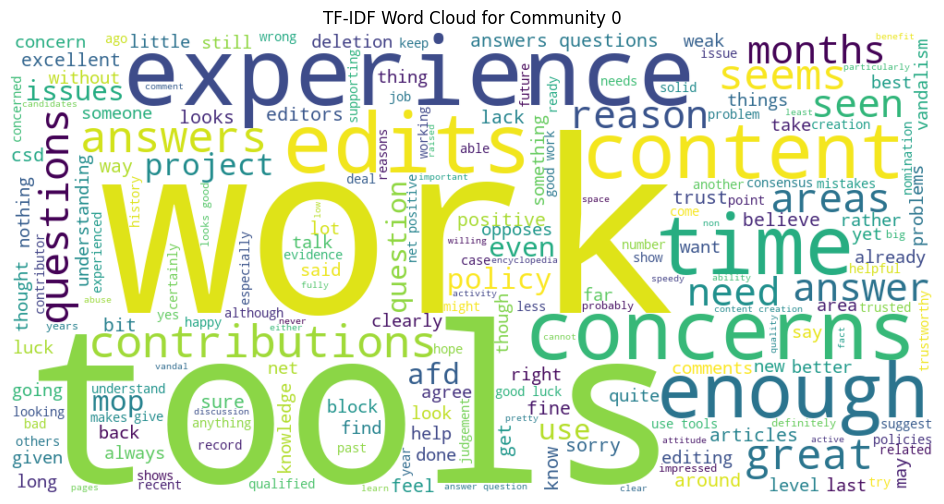

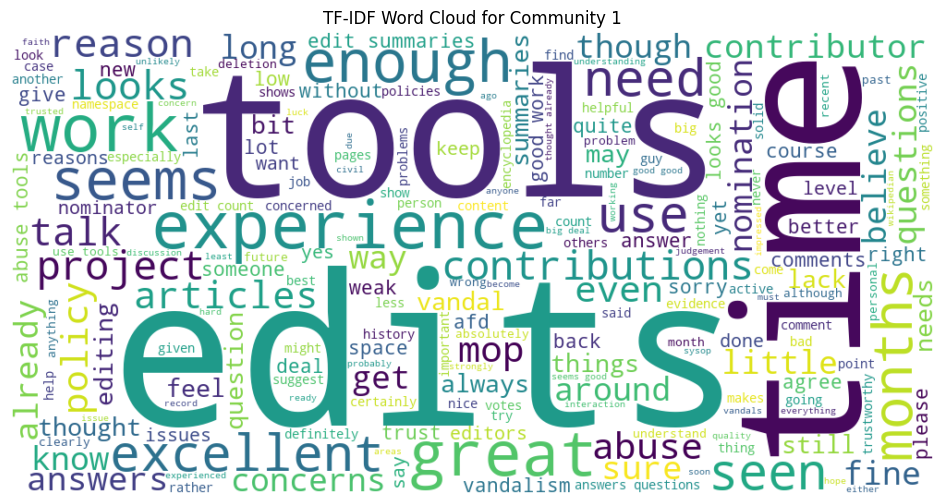

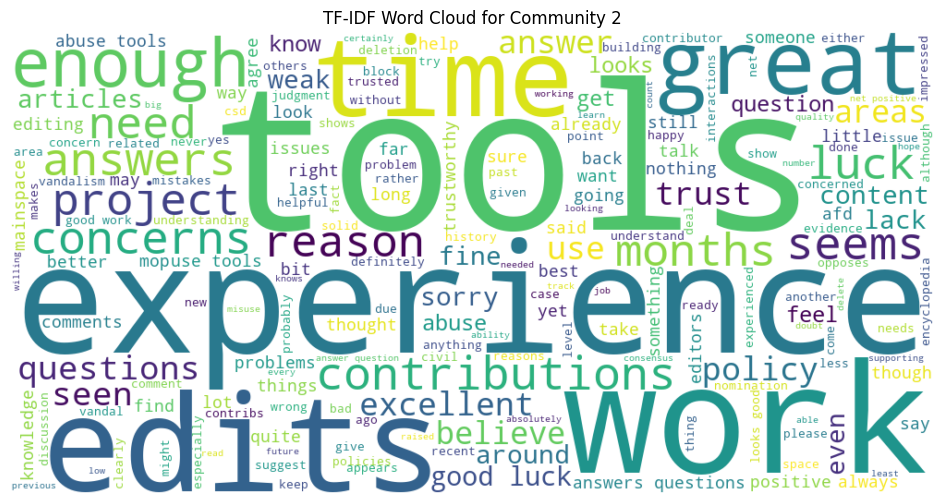

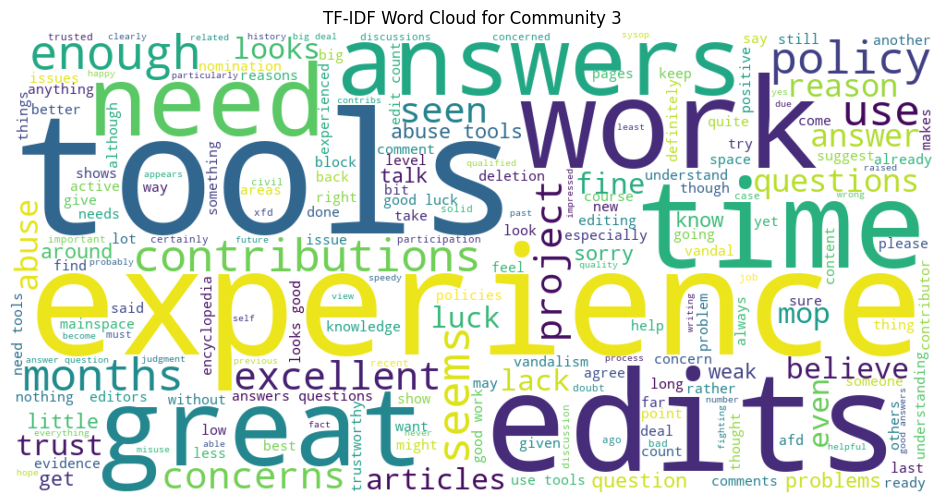

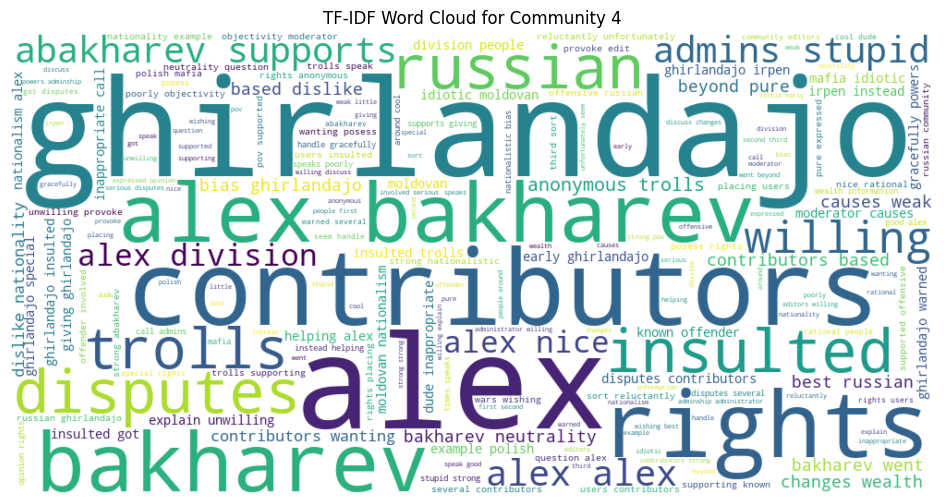

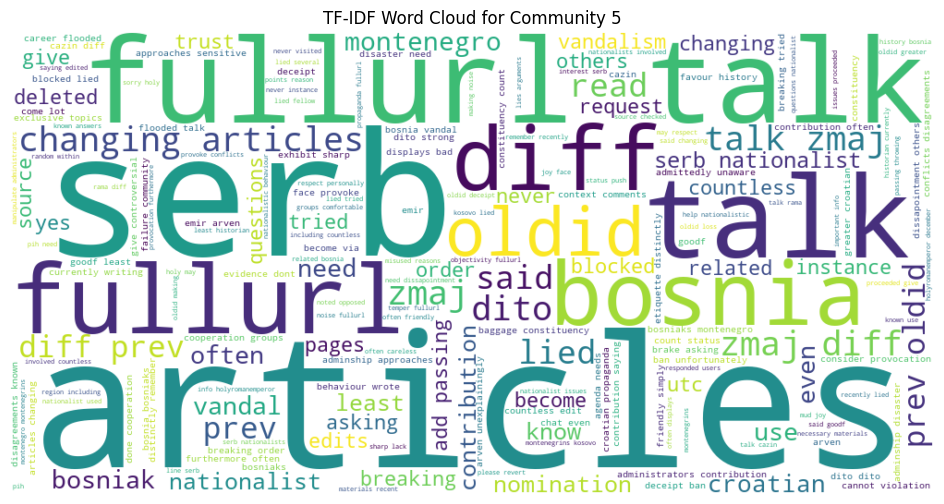

In [16]:
for c in community_ids:
    row = tfidf_df.loc[f"community_{c}"]
    
    freq_dict = row[row > 0].to_dict()

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for Community {c}")
    plt.show()